<a href="https://colab.research.google.com/github/ZataraHere/Basic-Neural-Networks/blob/main/logistic_regression_from_scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [42]:
import numpy as np
import copy
import matplotlib.pyplot as plt
import sklearn
import sklearn.datasets
from sklearn.linear_model import LogisticRegressionCV
from sklearn.metrics import accuracy_score

Load the Dataset


In [23]:
dataset = sklearn.datasets.load_breast_cancer()
Y, X = dataset.target, dataset.data

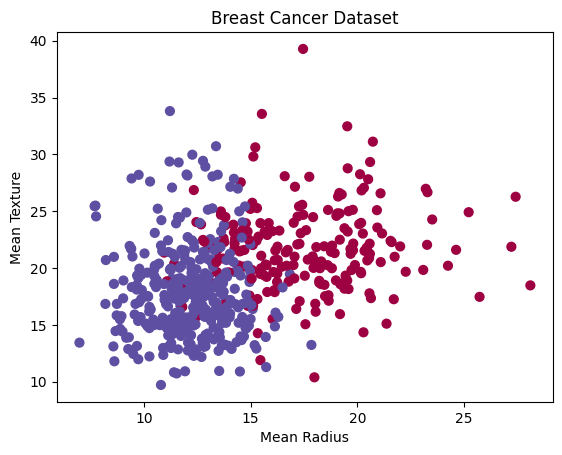

In [35]:
plt.scatter(X[:,0], X[:,1], c=Y, s=40, cmap = plt.cm.Spectral)
plt.xlabel('Mean Radius')
plt.ylabel('Mean Texture')
plt.title("Breast Cancer Dataset")
plt.show()

In [47]:
Y= Y.reshape(Y.shape[0], 1)

In [48]:
X.shape, Y.shape

((569, 30), (569, 1))

In [37]:
m = X.shape[0]

Simple Logistic Regression

In [40]:
clf = sklearn.linear_model.LogisticRegressionCV()
clf.fit(X, Y)


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

LogisticRegressionCV()

In [43]:
lr_predictions = clf.predict(X)
accuracy_score(Y, lr_predictions)

0.9701230228471002

Layer Sizes


In [108]:
def layer_sizes(X, Y):
  n_x = X.shape[1]
  n_h = 4
  n_y = Y.shape[1]
  return n_x, n_h, n_y

***1. Initialize Parameters***

In [109]:
def initialize_parameters(n_x, n_h, n_y):
  W1 = np.random.randn(n_x, n_h) * 0.01
  W2 = np.random.randn(n_h, n_y) * 0.01
  b1 = np.zeros((1, n_h))
  b2= np.zeros((1, n_y))

  parameters  = {
      "W1": W1,
       "W2": W2,
       "b1": b1,
       "b2": b2
  }

  return parameters

In [110]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

***2. Forward Propagation***

In [111]:
def forward_propagation(X, parameters):
  W1 = parameters["W1"]
  W2 = parameters["W2"]
  b1 = parameters["b1"]
  b2 = parameters["b2"]

  Z1 = np.dot(X, W1) + b1
  A1 = np.tanh(Z1)
  Z2 = np.dot(A1, W2) + b2
  A2 = sigmoid(Z2)

  cache = {
      "Z1":Z1,
      "A1":A1,
      "Z2":Z2,
      "A2":A2
  }

  return A2, cache

 ***3. Compute the Cost***

In [112]:
def compute_cost(A2, Y):
    m = Y.shape[0]
    # Use element-wise multiplication (*) and add a tiny epsilon for numerical stability
    cost = -1/m * np.sum(Y * np.log(A2 + 1e-8) + (1 - Y) * np.log(1 - A2 + 1e-8))
    cost = np.squeeze(cost)
    return cost

***4. Backpropagation***


In [118]:
def backpropagation(parameters, cache, X, Y):
    m = X.shape[0]

    W1 = parameters["W1"]
    W2 = parameters["W2"]
    b1 = parameters["b1"]
    b2 = parameters["b2"]

    A1 = cache["A1"]
    A2 = cache["A2"]

    # Backward pass: calculate dZ2, dW2, db2
    dZ2 = A2 - Y
    dW2 = 1/m * (A1.T @ dZ2)                    # Fixed: A1.T @ dZ2 matches (n_h, n_y)
    db2 = 1/m * np.sum(dZ2, axis=0, keepdims=True) # Fixed: axis=0 to match (1, n_y)

    # Backward pass: calculate dZ1, dW1, db1
    g1 = 1 - np.power(A1, 2)
    dZ1 = np.multiply((dZ2 @ W2.T), g1)          # Fixed order for matmul: dZ2 @ W2.T
    dW1 = 1/m * (X.T @ dZ1)                     # Fixed: X.T @ dZ1 matches (n_x, n_h)
    db1 = 1/m * np.sum(dZ1, axis=0, keepdims=True) # Fixed: axis=0 to match (1, n_h)

    grads = {
        "dW1": dW1,
        "dW2": dW2,
        "db1": db1,
        "db2": db2
    }

    return grads

***5. Update Parameters***

In [119]:
def update_parameters(parameters, grads, learning_rate = 1.2):


  W1 = parameters["W1"]
  W2 = parameters["W2"]
  b1 = parameters["b1"]
  b2 = parameters["b2"]

  dW1 = grads["dW1"]
  dW2 = grads["dW2"]
  db1 = grads["db1"]
  db2 = grads["db2"]

  W1 = W1 - learning_rate * dW1
  W2 = W2 - learning_rate * dW2
  b1 = b1 - learning_rate * db1
  b2 = b2 - learning_rate * db2

  parameters  = {
      "W1": W1,
       "W2": W2,
       "b1": b1,
       "b2": b2
  }

  return parameters

***6. Integration***

In [120]:
def nn_model(X, Y, n_h, num_iterations = 10000, print_cost = False):
    np.random.seed(3)
    n_x = layer_sizes(X, Y)[0]
    n_y = layer_sizes(X, Y)[2]

    parameters = initialize_parameters(n_x, n_h, n_y)

    for i in range(0, num_iterations):
        A2, cache = forward_propagation(X, parameters)
        cost = compute_cost(A2, Y)
        grads = backpropagation(parameters, cache, X, Y)

        parameters = update_parameters(parameters, grads)  # Fixed: passed grads instead of cache

        if print_cost and i % 1000 == 0:
            print("Cost after iteration %i : %f" % (i, cost))

    return parameters

***7. test the model***

In [121]:
def predict(parameters, X):
  A2, cache = forward_propagation(X, parameters)
  predictions = np.round(A2)
  return predictions

***8. test the model on planar dataset***

In [123]:
parameters = nn_model(X, Y, n_h = 4, num_iterations= 10000, print_cost=True)
predictions  = predict(parameters, X)
accuracy_score(Y, predictions)

Cost after iteration 0 : 0.688789
Cost after iteration 1000 : 0.660316
Cost after iteration 2000 : 0.660316
Cost after iteration 3000 : 0.660316
Cost after iteration 4000 : 0.660316
Cost after iteration 5000 : 0.660316
Cost after iteration 6000 : 0.660316
Cost after iteration 7000 : 0.660316
Cost after iteration 8000 : 0.660316
Cost after iteration 9000 : 0.660316


0.6274165202108963